# Metric

## T1

In [1]:
# T1
print(f"T1. The accuracy of Model A is {70/100}")

T1. The accuracy of Model A is 0.7


## T2

In [2]:
# T2
pre = 40 / 60
rec = 40 / 50
print(f"Precision: {pre}")
print(f"Recall: {rec}")
print(f"F1: {2*(pre*rec)/(pre+rec)}")

Precision: 0.6666666666666666
Recall: 0.8
F1: 0.7272727272727272


## T3

In [3]:
# T3
pre = 30 / 40
rec = 30 / 50
print(f"Precision: {pre}")
print(f"Recall: {rec}")
print(f"F1: {2*(pre*rec)/(pre+rec)}")

Precision: 0.75
Recall: 0.6
F1: 0.6666666666666665


In [4]:
# T4


## OT1.
- The accuracy > F1 when TN > TP
- The accuracy = F1 when TN = TP
- The accuracy < F1 when TN < TP

# Clustering

In [3]:
import numpy as np

In [6]:
def distance(p1,p2): # Euclidean distance
    return np.sqrt(np.sum((p1 - p2) ** 2))

In [89]:
class Cluster:
    flag = True
    cluster = {}
    data=[]
    k = 0

    def __init__(self, data, k, cluster=None):
        self.data = data
        self.k = k
        self.cluster = cluster if cluster is not None else {}
        if not cluster:
            for i in range(k):
                self.cluster[i] = {
                    'center' : data[i],
                    'points': []
                }

    @classmethod
    def from_k(cls, k ,data):
        cluster = {}
        for i in range(k):
            cluster[i] = {"center": data[i], "points": []}
        return cls(data,k,cluster)
    @classmethod
    def from_cen(cls, cen, data):
        k = len(cen)
        cluster = {}
        for i in range(len(cen)):
            cluster[i] = {"center": cen[i], "points": []}
        return cls(data,len(cen),cluster)

    def all_data_centroid(self):
        return np.mean(self.data, axis=0)
    def btw_clus_var(self):
        res = 0
        M = self.all_data_centroid()
        for i in range(self.k):
            n_i = len(self.cluster[i]['points'])
            res += n_i * np.sum((self.cluster[i]['center'] - M)**2)
        return res/(len(self.data)-1)

    def all_data_var(self):
        M = self.all_data_centroid()
        res = np.sum((self.data - M)**2)
        return res/(len(self.data)-1)

    def frac_var(self):
        return (self.btw_clus_var()/self.all_data_var())

    def assign(self):  # Assign Cluster
        for i in range(self.k): # Clear points from previous iteration
            self.cluster[i]["points"] = []

        for p in self.data: 
            dist = []
            for i in range(self.k):
                cur_cluster = self.cluster[i]['center']
                dist.append(distance(cur_cluster,p))
            cur_cluster = np.argmin(dist)
            self.cluster[cur_cluster]['points'].append(p)
            # print(f"Assign {p} to {self.cluster[cur_cluster]['center']}")

    def update(self):  # Update each centroid
        self.flag = False
        for i in range(self.k): 
            points = np.array(self.cluster[i]['points'])
            mean_p = points.mean(axis = 0)
            if not np.array_equal(mean_p, self.cluster[i]['center']):
                self.flag = True
                # print(f"Update {self.cluster[i]['center']} to {mean_p}")
                self.cluster[i]['center'] = mean_p

    def start_cluster(self):
        while self.flag:
            self.assign()
            self.update()

## T5

In [92]:
# T5
data = np.array([(1,2),(3,3),(2,2),(8,8),(6,6),(7,7),(-3,-3),(-2,-4),(-7,-7)])
cen = [(3,3),(2,2),(-3,-3)]
k=len(cen)

In [53]:
cluster = Cluster.from_cen(cen, data)
cluster.start_cluster()

Assign [1 2] to (2, 2)
Assign [3 3] to (3, 3)
Assign [2 2] to (2, 2)
Assign [8 8] to (3, 3)
Assign [6 6] to (3, 3)
Assign [7 7] to (3, 3)
Assign [-3 -3] to (-3, -3)
Assign [-2 -4] to (-3, -3)
Assign [-7 -7] to (-3, -3)
Update (3, 3) to [6. 6.]
Update (2, 2) to [1.5 2. ]
Update (-3, -3) to [-4.         -4.66666667]
Assign [1 2] to [1.5 2. ]
Assign [3 3] to [1.5 2. ]
Assign [2 2] to [1.5 2. ]
Assign [8 8] to [6. 6.]
Assign [6 6] to [6. 6.]
Assign [7 7] to [6. 6.]
Assign [-3 -3] to [-4.         -4.66666667]
Assign [-2 -4] to [-4.         -4.66666667]
Assign [-7 -7] to [-4.         -4.66666667]
Update [6. 6.] to [7. 7.]
Update [1.5 2. ] to [2.         2.33333333]
Assign [1 2] to [2.         2.33333333]
Assign [3 3] to [2.         2.33333333]
Assign [2 2] to [2.         2.33333333]
Assign [8 8] to [7. 7.]
Assign [6 6] to [7. 7.]
Assign [7 7] to [7. 7.]
Assign [-3 -3] to [-4.         -4.66666667]
Assign [-2 -4] to [-4.         -4.66666667]
Assign [-7 -7] to [-4.         -4.66666667]


## T6

In [54]:
# T6
cluster = Cluster.from_cen([(-3, -3), (2, 2), (-7, -7)], data)
cluster.start_cluster()

Assign [1 2] to (2, 2)
Assign [3 3] to (2, 2)
Assign [2 2] to (2, 2)
Assign [8 8] to (2, 2)
Assign [6 6] to (2, 2)
Assign [7 7] to (2, 2)
Assign [-3 -3] to (-3, -3)
Assign [-2 -4] to (-3, -3)
Assign [-7 -7] to (-7, -7)
Update (-3, -3) to [-2.5 -3.5]
Update (2, 2) to [4.5        4.66666667]
Assign [1 2] to [4.5        4.66666667]
Assign [3 3] to [4.5        4.66666667]
Assign [2 2] to [4.5        4.66666667]
Assign [8 8] to [4.5        4.66666667]
Assign [6 6] to [4.5        4.66666667]
Assign [7 7] to [4.5        4.66666667]
Assign [-3 -3] to [-2.5 -3.5]
Assign [-2 -4] to [-2.5 -3.5]
Assign [-7 -7] to (-7, -7)


## T7
In my opinion the optimal starting point is the one that minimize number of assign and update iteration.

## OT2

K=1: Explained Variance = 0.0000
K=2: Explained Variance = 0.6633 (Gain: 0.6633)
K=3: Explained Variance = 0.9299 (Gain: 0.2665)
K=4: Explained Variance = 0.9350 (Gain: 0.0052)
Gain 0.0052 is below threshold 0.05. Stopping.
Optimal K found: 3


Text(0, 0.5, 'Fraction of explained variance')

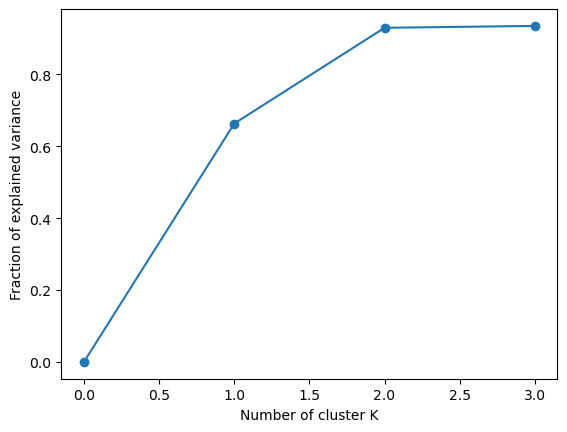

In [96]:
# Configuration
k = 1
prev_frac = 0.0
threshold = 0.05  # Stop if improvement is less than 5%
optimal_k = 1

# Initial Run for K=1
cluster = Cluster.from_k(k, data)
cluster.start_cluster()
current_frac = cluster.frac_var()

record = [current_frac]

print(f"K={k}: Explained Variance = {current_frac:.4f}")

while True:
    k += 1

    # Store previous variance
    prev_frac = current_frac

    # Run new cluster
    cluster = Cluster.from_k(k, data)
    cluster.start_cluster()
    current_frac = cluster.frac_var()

    record.append(current_frac)

    # Calculate the gain
    gain = current_frac - prev_frac

    print(f"K={k}: Explained Variance = {current_frac:.4f} (Gain: {gain:.4f})")

    # STOPPING CONDITION:
    # If the gain is smaller than our threshold, the previous K was the "Elbow"
    if gain < threshold:
        optimal_k = k - 1
        print(f"Gain {gain:.4f} is below threshold {threshold}. Stopping.")
        break

    # Safety break to prevent infinite loops if data is weird
    if k > 20:
        print("Reached max K limit.")
        optimal_k = k
        break

print(f"Optimal K found: {optimal_k}")
plt.plot(list(range(len(record))), record, '-o')
plt.xlabel('Number of cluster K')
plt.ylabel("Fraction of explained variance")

By the Elbow method, the optimal number of cluster is K=3. While the explained variance continue to increase with higher K, the marginal gain after K=3 is very little (diminishing return), indicate that adding more cluster may overfitting rather than meaning full cluster seperation.

## My heart will go on?

In [2]:
import numpy as np
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

In [3]:
train_url = "http://s3.amazonaws.com/assets.datacamp.com/course/Kaggle/train.csv"
train = pd.read_csv(train_url)  # training set
test_url = "http://s3.amazonaws.com/assets.datacamp.com/course/Kaggle/test.csv"
test = pd.read_csv(test_url)  # test set

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## T8

In [5]:
# impute na data with median
print(f"The median of the Age is {train["Age"].median()}")
train["Age"] = train["Age"].fillna(train["Age"].median())

The median of the Age is 28.0


## T9

In [6]:
train.loc[train["Embarked"] == "S", "Embarked"] = 0
train.loc[train["Embarked"] == "C", "Embarked"] = 1
train.loc[train["Embarked"] == "Q", "Embarked"] = 2
print(f"The mode of Embarked is {train["Embarked"].mode()[0]}")
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])

The mode of Embarked is 0


In [7]:
train.loc[train["Sex"] == "male","Sex"] = 0
train.loc[train["Sex"] == "female", "Sex"] = 1
print(f"the mode of Sex is {train["Sex"].mode()[0]}")
train["Sex"] = train["Sex"].fillna(train["Sex"].mode()[0])


the mode of Sex is 0


## T10

In [8]:
data = np.array(train[["Pclass", "Sex", "Age", "Embarked"]].values, dtype = int)

In [9]:
def feature_prep(df):
    df = df.copy()
    df["Age"] = df["Age"].fillna(df["Age"].median())
    df.loc[df["Embarked"] == "S", "Embarked"] = 0
    df.loc[df["Embarked"] == "C", "Embarked"] = 1
    df.loc[df["Embarked"] == "Q", "Embarked"] = 2
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
    df.loc[df["Sex"] == "male", "Sex"] = 0
    df.loc[df["Sex"] == "female", "Sex"] = 1
    df["Sex"] = df["Sex"].fillna(df["Sex"].mode()[0])
    return df

In [10]:
# LMS Class

class LMSRegression:
    def __init__(self, learning_rate, n_iterations=1000):
        self.lr = learning_rate
        self.n_it = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # init var
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient descenttt
        for i in range(self.n_it):
            # pred
            y_pred = np.dot(X, self.weights) + self.bias # y = mx + c

            # Calculate Gradient Desc
            dw = np.dot(X.T, (y - y_pred)) # Gradient Sum
            db = np.sum(y-y_pred)

            self.weights = self.weights + (self.lr * dw)
            self.bias = self.bias + (self.lr * db)

            # if i % 100 == 0:
                # print(f"Iter {i}")
    def predict(self, X, threshold=0.5):
        return ((np.dot(X, self.weights) + self.bias) >= threshold).astype(int)

In [11]:
model = LMSRegression(learning_rate=0.000001, n_iterations = 5000)
y = np.array(train["Survived"])
model.fit(X=data, y=y)

feature = ["Pclass","Sex","Age","Embarked"]
test_df = feature_prep(test)[["PassengerId"] + feature]
res = model.predict(test_df[feature], threshold=0.5)
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": res
})
print(submission.head())
submission.to_csv("submission/submission.csv", index=False)

   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


In [12]:
def get_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [13]:
train_res = model.predict(train[feature], threshold=0.5)
print(f"Train accuracy with features({feature}): {get_accuracy(train["Survived"],train_res)}")

Train accuracy with features(['Pclass', 'Sex', 'Age', 'Embarked']): 0.792368125701459


## T11
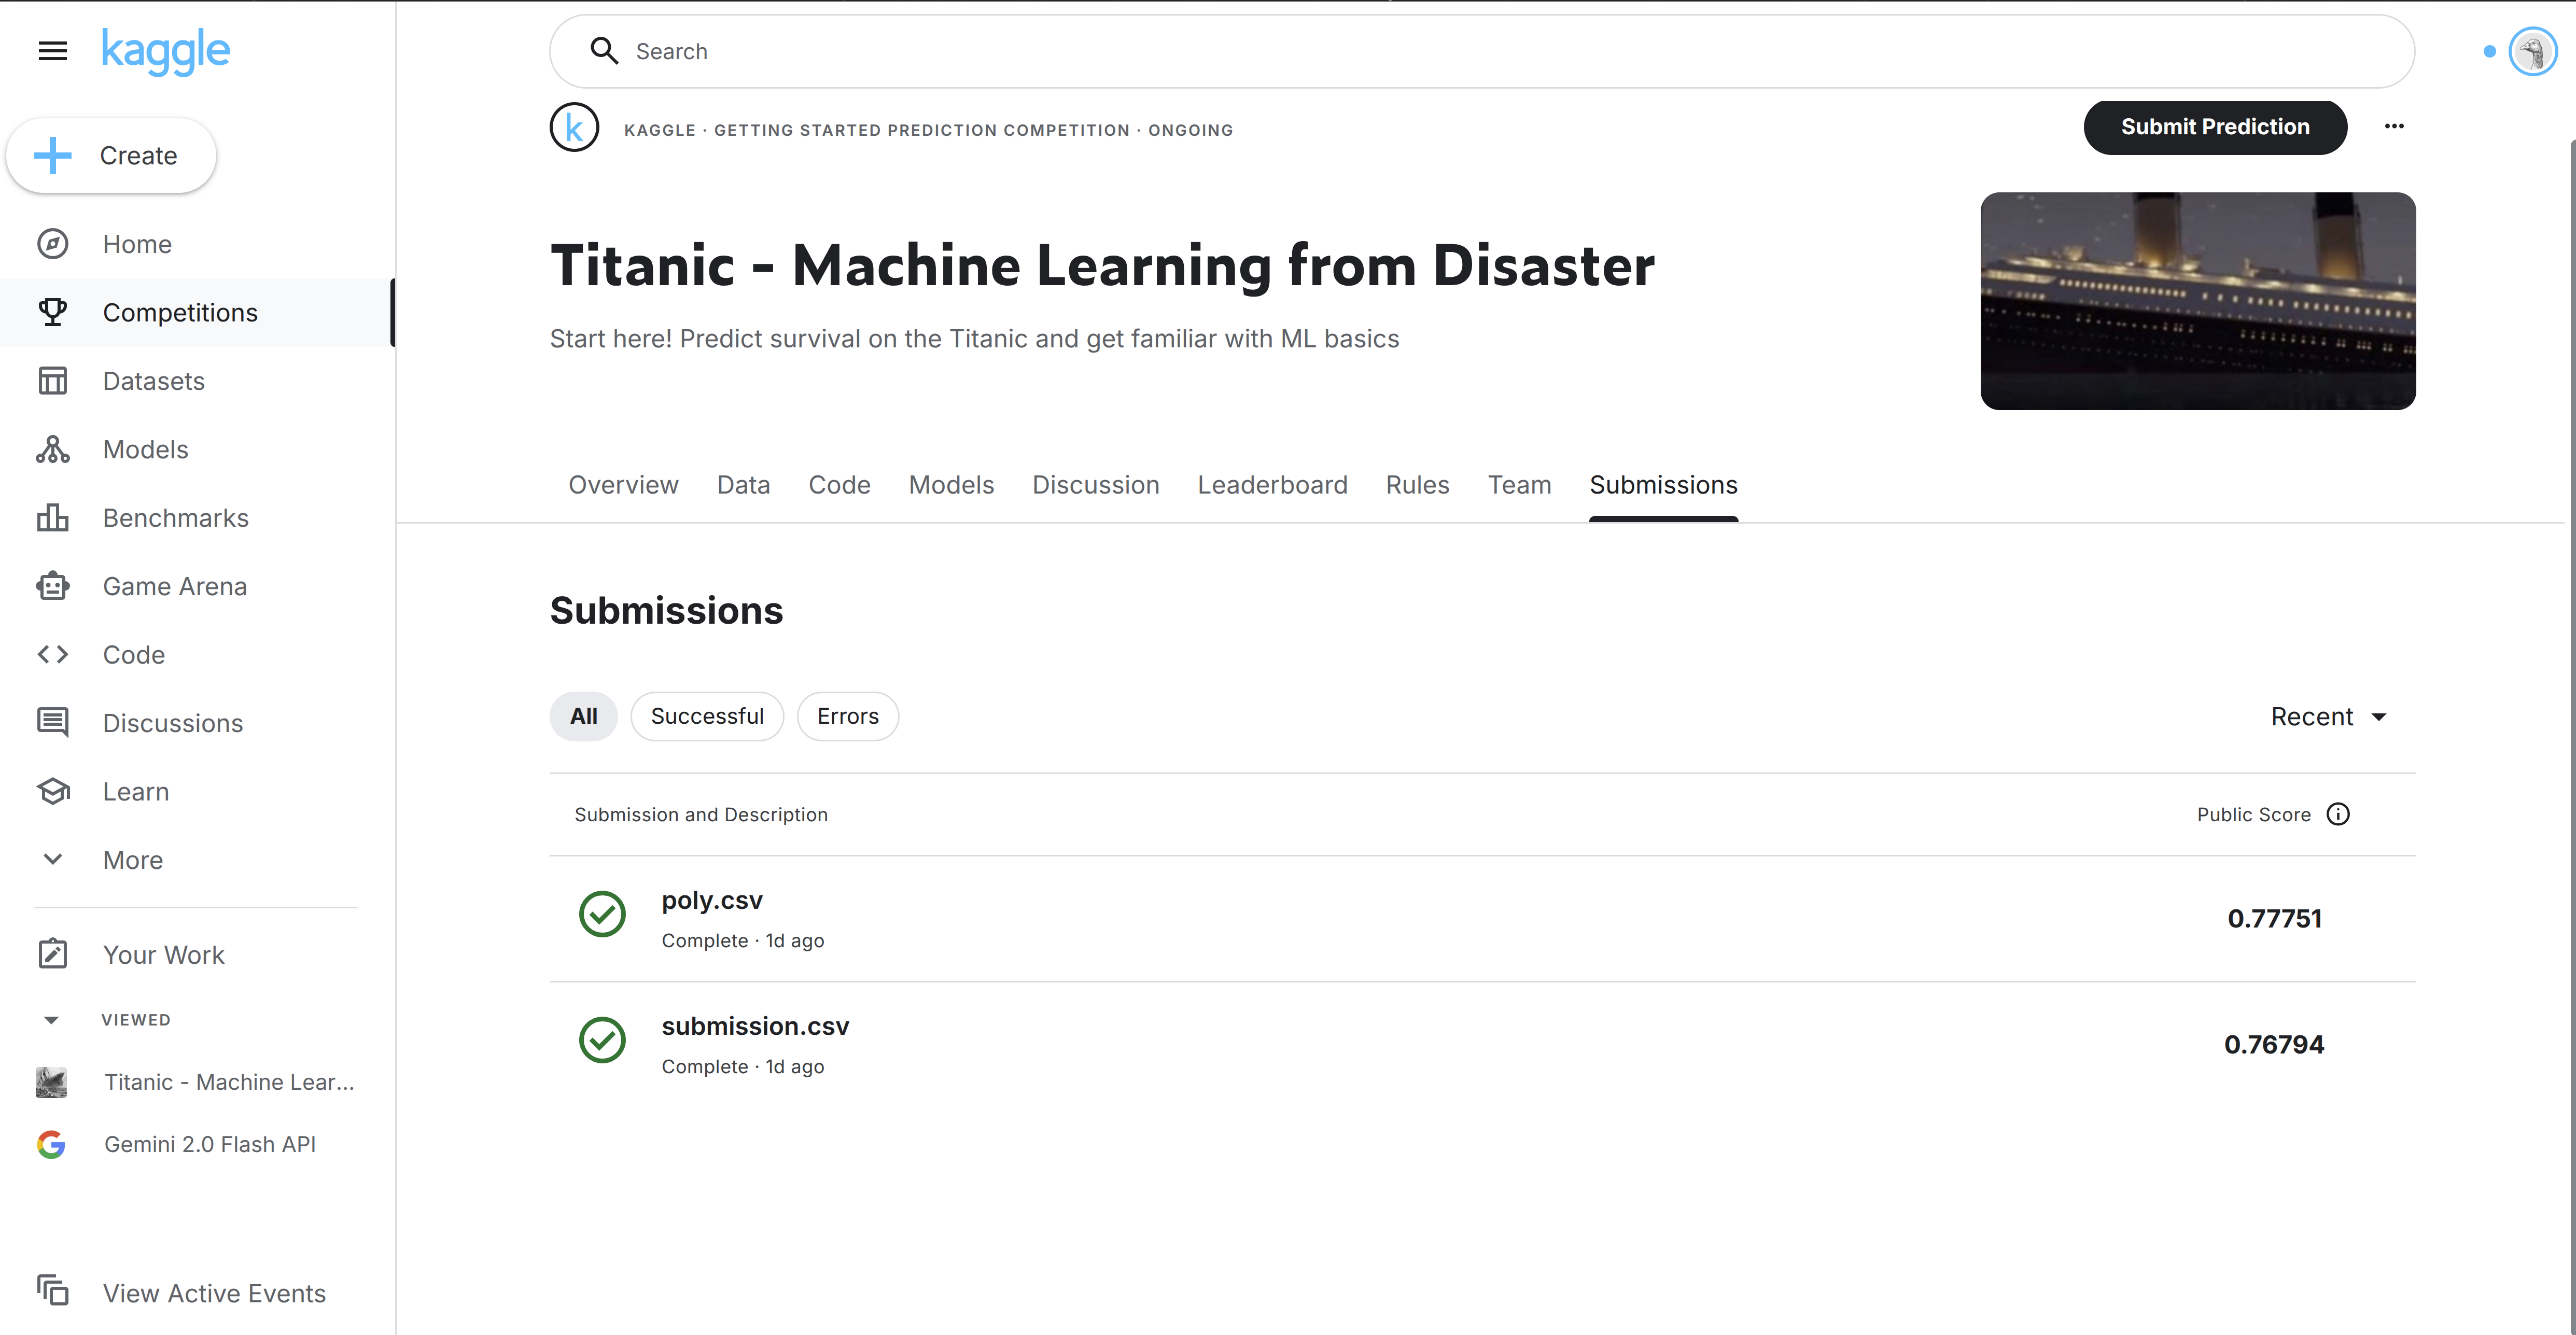
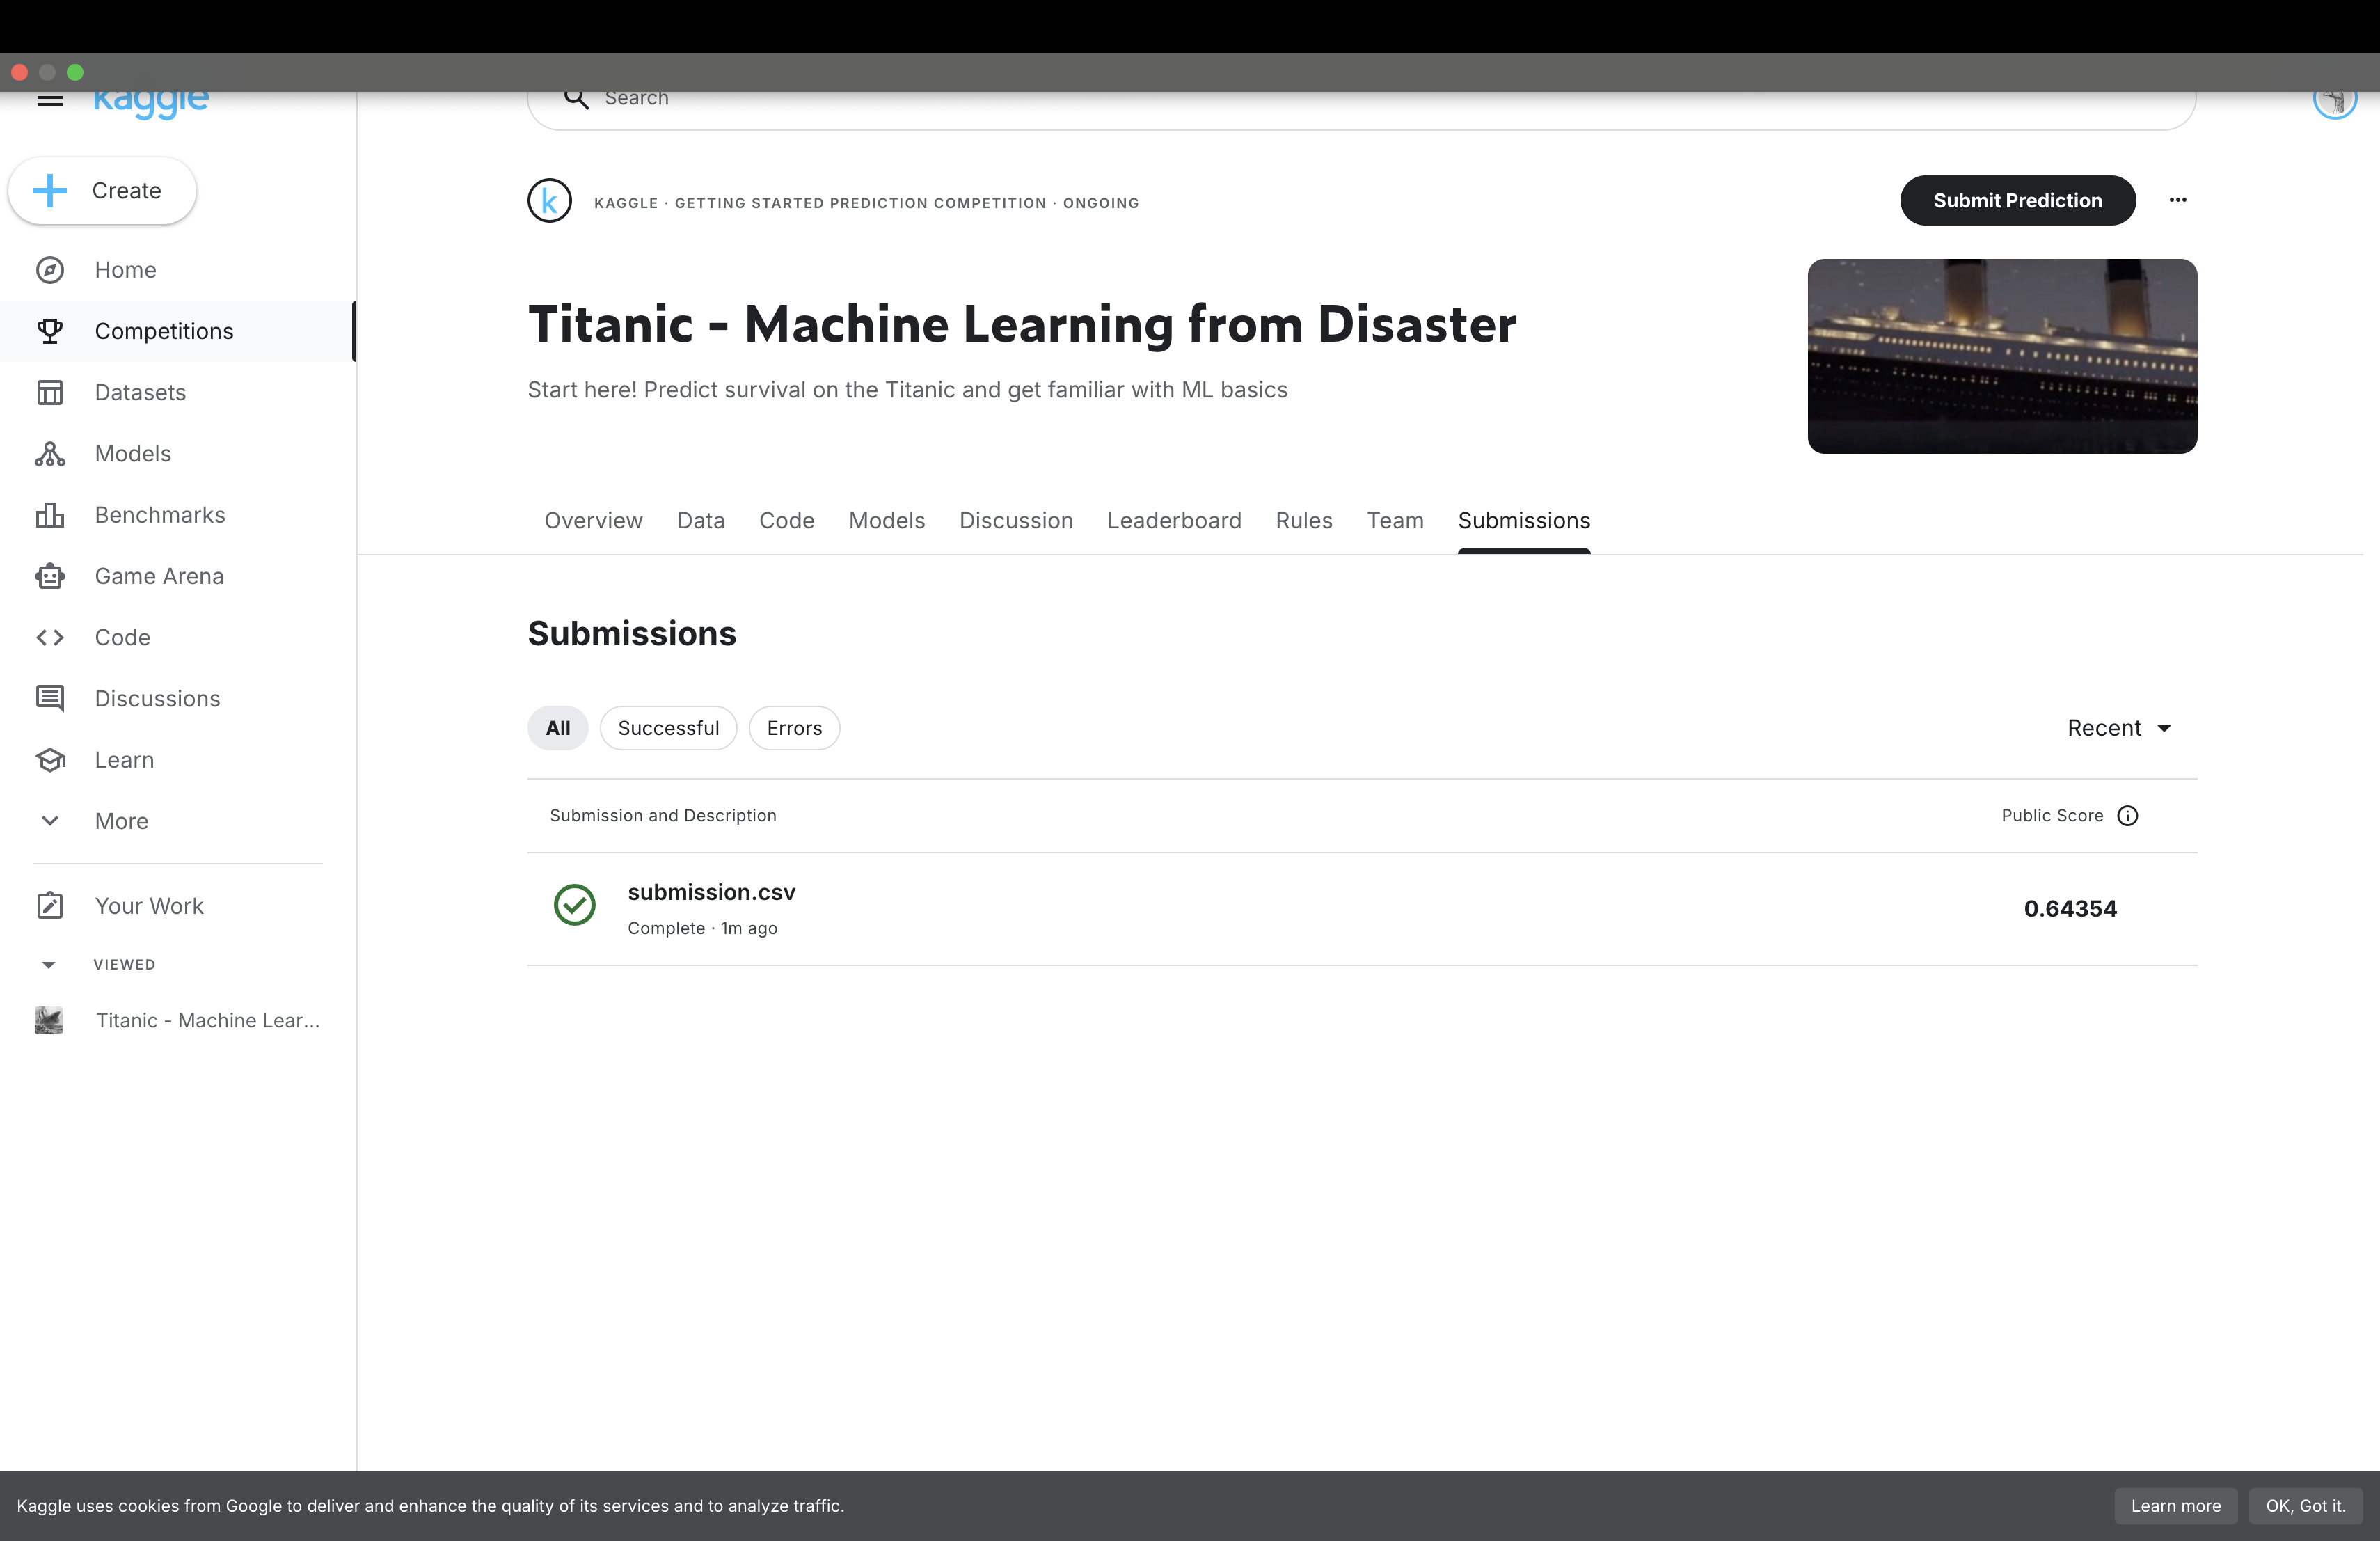

## T12
Try adding some higher order features to your training (x21, x1x2,...).

In [14]:
def get_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def add_poly_features(X):
    n_samples, n_features = X.shape
    new_features = [X]
    # Squared terms
    new_features.append(X ** 2)
    # Interaction terms
    for i in range(n_features):
        for j in range(i + 1, n_features):
            new_features.append((X[:, i] * X[:, j]).reshape(-1, 1))
            
    return np.hstack(new_features)

def normalize_features(X, mean=None, std=None):
    if mean is None or std is None:
        mean = np.mean(X, axis=0)
        std = np.std(X, axis=0)
        # Prevent division by zero
        std[std == 0] = 1
    return (X - mean) / std, mean, std

# Prepare Data
X_poly = add_poly_features(data)
# Normalize training data
X_poly_norm, mean_poly, std_poly = normalize_features(X_poly)
y = np.array(train["Survived"])

# Train Model
# Now we can use a standard learning rate since data is normalized
model_poly = LMSRegression(learning_rate=0.0001, n_iterations=500) 
model_poly.fit(X_poly_norm, y)

# Check Training Accuracy
train_pred = model_poly.predict(X_poly_norm)
acc = get_accuracy(y, train_pred)
print(f"T12: Training Accuracy with Higher Order Features: {acc:.4f}")

# Predict on Test Set
test_features_base = np.array(feature_prep(test)[["Pclass", "Sex", "Age", "Embarked"]].values, dtype=float) 
X_test_poly = add_poly_features(test_features_base)

# IMPORTANT: Use training mean/std to normalize test set
X_test_poly_norm, _, _ = normalize_features(X_test_poly, mean_poly, std_poly)

test_pred = model_poly.predict(X_test_poly_norm)
submission = pd.DataFrame({
    'PassengerId': test["PassengerId"],
    'Survived': test_pred
})
submission.to_csv("submission/poly.csv", index=False)

T12: Training Accuracy with Higher Order Features: 0.8159


Ans: The result with higher order feature have better accuracy because it expand and show relation-ship between feature.

## T13
What happens if you reduce the amount of features to just Sex and Age?

In [15]:
# Select Sex and Age
X_reduced = data[:, [1, 2]]

# Train Model
model_reduced = LMSRegression(learning_rate=0.0001, n_iterations=1000)
model_reduced.fit(X_reduced, y)

# Check Accuracy
train_pred_reduced = model_reduced.predict(X_reduced)
acc_reduced = get_accuracy(y, train_pred_reduced)
print(f"T13: Training Accuracy with Sex and Age only: {acc_reduced:.4f}")

T13: Training Accuracy with Sex and Age only: 0.6162


Ans: The training accuracy is reduced since the model got less feature to learn.

## OT3. 
We want to show that matrix inversion yields the same answer as the gradient descent method. However, there is no closed form solution for logistic regression. Thus, we will use normal linear regression instead. Re-do the Titanic task as a regression problem by using linear regression. Use the gradient descent method.

In [16]:
# We use the full features (Pclass, Sex, Age, Embarked) from the earlier step
X_ot3 = data.astype(float)
y_ot3 = np.array(train["Survived"])

# Normalize to prevent gradient explosion/NaN
X_ot3_norm, mean_ot3, std_ot3 = normalize_features(X_ot3)

# With normalized data, we can use a larger learning rate
model_gd = LMSRegression(learning_rate=0.001, n_iterations=10000)
model_gd.fit(X_ot3_norm, y_ot3)


print("OT3: Gradient Descent Model Trained (on normalized data).")
print(f"Bias: {model_gd.bias}")
print(f"Weights: {model_gd.weights}")

OT3: Gradient Descent Model Trained (on normalized data).
Bias: 0.3838383838383838
Weights: [-0.15750235  0.23451333 -0.06588277  0.03117705]


## OT4. 
Now try using matrix inversion instead. However Are the weights learned from the two methods similar? Report the Mean Squared Errors (MSE) of the difference between the two weights.

In [17]:
# Use the NORMALIZED data (same as GD) for fair comparison
X_aug = np.column_stack((X_ot3_norm, np.ones(X_ot3_norm.shape[0])))

# Normal Equation: w = (X^T * X)^-1 * X^T * y
try:
    w_inv = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y_ot3
except np.linalg.LinAlgError:
    print("Matrix is singular, using pseudo-inverse.")
    w_inv = np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T @ y_ot3

# Construct combined weights for GD model (weights + bias at the end)
w_gd_combined = np.append(model_gd.weights, model_gd.bias)

print("Weights from Matrix Inversion (on normalized data):", w_inv)
print("Weights from Gradient Descent (on normalized data):", w_gd_combined)

# Calculate MSE of weight differences
mse_weights = np.mean((w_gd_combined - w_inv)**2)
print(f"MSE of the difference between the two weights: {mse_weights:.6e}")

Weights from Matrix Inversion (on normalized data): [-0.15750235  0.23451333 -0.06588277  0.03117705  0.38383838]
Weights from Gradient Descent (on normalized data): [-0.15750235  0.23451333 -0.06588277  0.03117705  0.38383838]
MSE of the difference between the two weights: 5.030529e-32
